# DEAI-opdrachten Lineaire Regressie

Dit notebook bevat de implementatie van een lineair regressiemodel voor het voorspellen van huisprijzen in Ames, Iowa, gebaseerd op de AmesHousing dataset.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

pad_excel = r'C:\Users\raymo\Documents\DEAI_portfolio\Opdracht 6.0\AmesHousing.xlsx'
pad_csv = r'C:\Users\raymo\Documents\DEAI_portfolio\Opdracht 6.0\AmesHousing.xlsx - AmesHousing.csv'

try:
    df = pd.read_csv(pad_csv)
    print("✅ Succes: CSV bestand ingeladen.")
except:
    try:
        df = pd.read_excel(pad_excel, sheet_name='AmesHousing')
        print("✅ Succes: Excel bestand ingeladen.")
    except Exception as e:
        print(f"❌ Error: Kon het bestand niet vinden. Foutmelding: {e}")

target = 'SalePrice'
features = ['Overall Qual', 'Gr Liv Area', 'Neighborhood']
X = df[features]
y = df[target]

X_encoded = pd.get_dummies(X, columns=['Neighborhood'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SGDRegressor(eta0=0.01, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("\n" + "="*30)
print("="*30)
print(f"MAE (Gemiddelde fout): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2 Score (Nauwkeurigheid): {r2_score(y_test, y_pred):.4f}")
print("="*30)

✅ Succes: Excel bestand ingeladen.

MAE (Gemiddelde fout): 24679.98
R2 Score (Nauwkeurigheid): 0.8071


## Feature selectie

Target: SalePrice  
Gekozen features (top 3, inclusief 1 categorisch):  
- Overall Qual (numeriek)  
- Gr Liv Area (numeriek)  
- Neighborhood (categorisch)

## Initieel model

Hyperparameters: eta0=0.01, max_iter=1000

## Experiment 2

Meer features toegevoegd: Year Built, Full Bath, Lot Area  
Hyperparameters aangepast: eta0=0.001, max_iter=5000

In [2]:
target = 'SalePrice'
features_exp2 = ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area']

df_clean = df[features_exp2 + [target]].dropna()
X_exp2 = df_clean[features_exp2]
y_exp2 = df_clean[target]

X_encoded_exp2 = pd.get_dummies(X_exp2, columns=['Neighborhood'], drop_first=True)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_encoded_exp2, y_exp2, test_size=0.2, random_state=42)

scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train2)
X_test_scaled2 = scaler2.transform(X_test2)

model2 = SGDRegressor(eta0=0.001, max_iter=5000, random_state=42)
model2.fit(X_train_scaled2, y_train2)

y_pred2 = model2.predict(X_test_scaled2)

print("\n" + "="*30)
print("RESULTATEN EXPERIMENT 2")
print("="*30)
print(f"Features: {features_exp2}")
print(f"Hyperparameters: eta0=0.001, max_iter=5000")
print(f"MAE (Gemiddelde fout): {mean_absolute_error(y_test2, y_pred2):.2f}")
print(f"R2 Score (Nauwkeurigheid): {r2_score(y_test2, y_pred2):.4f}")
print("="*30)


RESULTATEN EXPERIMENT 2
Features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area']
Hyperparameters: eta0=0.001, max_iter=5000
MAE (Gemiddelde fout): 23693.45
R2 Score (Nauwkeurigheid): 0.8189


## Experiment 3

Zelfde features als experiment 2, maar hogere learning rate en meer epochs.  
Hyperparameters: eta0=0.01, max_iter=10000

In [3]:
model3 = SGDRegressor(eta0=0.01, max_iter=10000, random_state=42)
model3.fit(X_train_scaled2, y_train2)

y_pred3 = model3.predict(X_test_scaled2)

print("\n" + "="*30)
print("RESULTATEN EXPERIMENT 3")
print("="*30)
print(f"Features: {features_exp2}")
print(f"Hyperparameters: eta0=0.01, max_iter=10000")
print(f"MAE (Gemiddelde fout): {mean_absolute_error(y_test2, y_pred3):.2f}")
print(f"R2 Score (Nauwkeurigheid): {r2_score(y_test2, y_pred3):.4f}")
print("="*30)


RESULTATEN EXPERIMENT 3
Features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area']
Hyperparameters: eta0=0.01, max_iter=10000
MAE (Gemiddelde fout): 23835.98
R2 Score (Nauwkeurigheid): 0.8154


## Experiment 4

Features aangepast: vervangen Lot Area door Total Bsmt SF (kelderoppervlak).  
Hyperparameters: eta0=0.005, max_iter=7500

In [4]:
target = 'SalePrice'
features_exp4 = ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Total Bsmt SF']

df_clean4 = df[features_exp4 + [target]].dropna()
X_exp4 = df_clean4[features_exp4]
y_exp4 = df_clean4[target]

X_encoded_exp4 = pd.get_dummies(X_exp4, columns=['Neighborhood'], drop_first=True)
X_train4, X_test4, y_train4, y_test4 = train_test_split(X_encoded_exp4, y_exp4, test_size=0.2, random_state=42)

scaler4 = StandardScaler()
X_train_scaled4 = scaler4.fit_transform(X_train4)
X_test_scaled4 = scaler4.transform(X_test4)

model4 = SGDRegressor(eta0=0.005, max_iter=7500, random_state=42)
model4.fit(X_train_scaled4, y_train4)

y_pred4 = model4.predict(X_test_scaled4)

print("\n" + "="*30)
print("RESULTATEN EXPERIMENT 4")
print("="*30)
print(f"Features: {features_exp4}")
print(f"Hyperparameters: eta0=0.005, max_iter=7500")
print(f"MAE (Gemiddelde fout): {mean_absolute_error(y_test4, y_pred4):.2f}")
print(f"R2 Score (Nauwkeurigheid): {r2_score(y_test4, y_pred4):.4f}")
print("="*30)


RESULTATEN EXPERIMENT 4
Features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Total Bsmt SF']
Hyperparameters: eta0=0.005, max_iter=7500
MAE (Gemiddelde fout): 23249.26
R2 Score (Nauwkeurigheid): 0.7440


## Experiment 5

Zelfde features als experiment 2, maar met L1 regularisatie (penalty='l1').  
Hyperparameters: eta0=0.001, max_iter=5000, penalty='l1'

In [5]:
model5 = SGDRegressor(eta0=0.001, max_iter=5000, penalty='l1', random_state=42)
model5.fit(X_train_scaled2, y_train2)

y_pred5 = model5.predict(X_test_scaled2)

print("\n" + "="*30)
print("RESULTATEN EXPERIMENT 5")
print("="*30)
print(f"Features: {features_exp2}")
print(f"Hyperparameters: eta0=0.001, max_iter=5000, penalty='l1'")
print(f"MAE (Gemiddelde fout): {mean_absolute_error(y_test2, y_pred5):.2f}")
print(f"R2 Score (Nauwkeurigheid): {r2_score(y_test2, y_pred5):.4f}")
print("="*30)


RESULTATEN EXPERIMENT 5
Features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area']
Hyperparameters: eta0=0.001, max_iter=5000, penalty='l1'
MAE (Gemiddelde fout): 23693.88
R2 Score (Nauwkeurigheid): 0.8189


## Samenvatting Experimenten

- **Initieel model**: MAE 24679.98, R2 0.8071  
- **Experiment 2**: Meer features + lagere eta0, hogere max_iter → MAE 23693.45, R2 0.8189  
- **Experiment 3**: Hogere eta0, nog hogere max_iter → MAE 23835.98, R2 0.8154  
- **Experiment 4**: Feature vervangen (Lot Area → Total Bsmt SF), eta0=0.005, max_iter=7500 → MAE 23249.26, R2 0.7440 (slechter)  
- **Experiment 5**: L1 regularisatie toegevoegd → MAE 23693.88, R2 0.8189 (vergelijkbaar met exp2)  

Beste prestaties met meer features en lagere learning rate. Total Bsmt SF verminderde nauwkeurigheid, mogelijk door missing data.

## Lineaire Regressie met LinearRegression (voorbeeld aanpak)

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Herlaad data voor verse start
df_lr = pd.read_excel(pad_excel, sheet_name='AmesHousing')
print("Data herladen voor LinearRegression aanpak")

# Selecteer features inclusief target (SalePrice)
selected_features = ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area', 'SalePrice']
df_lr = df_lr.loc[:, selected_features]
print("Geselecteerde features:", selected_features)

# Maak dummies voor categorische feature (Neighborhood)
dummies_dataframe = pd.get_dummies(df_lr.loc[:, ['Neighborhood']], drop_first=True)
print("Dummies gemaakt voor Neighborhood")

# Concat en drop originele categorische kolom
df_lr = pd.concat([df_lr, dummies_dataframe], axis=1)
df_lr = df_lr.drop(['Neighborhood'], axis=1)
print("DataFrame bijgewerkt met dummies")

# Prepareer X en y, verwijder rijen met missing SalePrice
df_clean_lr = df_lr.dropna(subset=['SalePrice'])
X_lr = df_clean_lr.drop('SalePrice', axis=1)
y_lr = df_clean_lr['SalePrice']
print(f"Data shape: X={X_lr.shape}, y={y_lr.shape}")

# Handle missing values in features (zoals Lot Area)
X_lr = X_lr.fillna(X_lr.median(numeric_only=True))
print("Missing values in features gevuld met median")

# Train-test split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr,
    y_lr,
    test_size=0.15,
    random_state=42
)
print(f"Train shape: {X_train_lr.shape}, Test shape: {X_test_lr.shape}")

# Train LinearRegression model
reg_model = LinearRegression()
reg_model.fit(X_train_lr, y_train_lr)
print("LinearRegression model getraind")

# Toon coefficients
coef = pd.Series(reg_model.coef_, index=X_lr.columns).sort_values()
print("\nLinear Regression weights (coefficients):")
print(coef)

print("\nIntercept:")
print(reg_model.intercept_)

# Voorspel
y_pred_lr = reg_model.predict(X_test_lr)
print("Voorspellingen gemaakt")

# Evalueer
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)
mse_lr = mean_squared_error(y_test_lr, y_pred_lr)
rmse_lr = mse_lr ** 0.5

print("\n" + "="*40)
print("RESULTATEN LINEAR REGRESSION")
print("="*40)
print(f"MAE (Gemiddelde Absolute Error): ${mae_lr:.2f}")
print(f"MSE (Mean Squared Error): ${mse_lr:.2f}")
print(f"RMSE (Root Mean Squared Error): ${rmse_lr:.2f}")
print("="*40)

Data herladen voor LinearRegression aanpak
Geselecteerde features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area', 'SalePrice']
Dummies gemaakt voor Neighborhood
DataFrame bijgewerkt met dummies
Data shape: X=(2930, 32), y=(2930,)
Missing values in features gevuld met median
Train shape: (2490, 32), Test shape: (440, 32)
LinearRegression model getraind

Linear Regression weights (coefficients):
Neighborhood_BrDale    -33168.417146
Neighborhood_Blueste   -26470.856459
Neighborhood_Landmrk   -25861.636270
Neighborhood_NPkVill   -13212.306044
Neighborhood_MeadowV   -13031.500356
Neighborhood_SWISU     -10014.682162
Neighborhood_Gilbert    -9707.196217
Neighborhood_SawyerW    -6152.024004
Full Bath               -5847.325834
Neighborhood_Edwards    -3045.219955
Neighborhood_NWAmes     -3039.054385
Neighborhood_IDOTRR     -1505.323771
Neighborhood_OldTown    -1477.392850
Lot Area                    0.991675
Gr Liv Area                57.474171
Neighbor

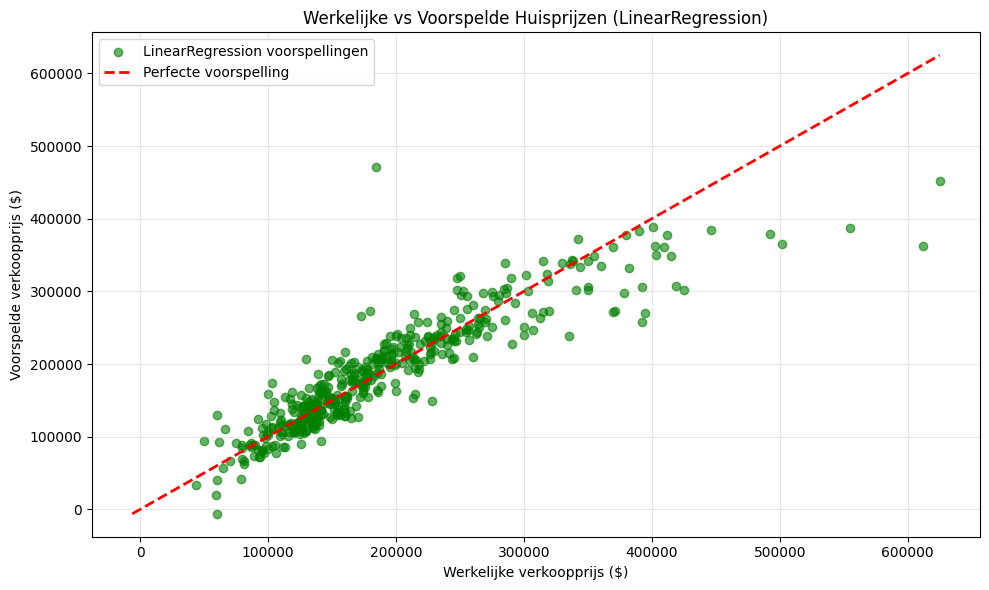

In [7]:
# Visualisatie voor LinearRegression model
plt.figure(figsize=(10, 6))
plt.scatter(y_test_lr, y_pred_lr, alpha=0.6, color='green', label='LinearRegression voorspellingen')

# Perfecte lijn
min_val_lr = min(y_test_lr.min(), y_pred_lr.min())
max_val_lr = max(y_test_lr.max(), y_pred_lr.max())
plt.plot([min_val_lr, max_val_lr], [min_val_lr, max_val_lr], color='red', linestyle='--', linewidth=2, label='Perfecte voorspelling')

plt.xlabel('Werkelijke verkoopprijs ($)')
plt.ylabel('Voorspelde verkoopprijs ($)')
plt.title('Werkelijke vs Voorspelde Huisprijzen (LinearRegression)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 30 Experimenten voor Logboek

In [8]:
# Deze cel is vervangen door de kleinere secties hieronder

In [9]:
# === DEEL 2: Feature sets definiëren ===
feature_sets = {
    1: ['Overall Qual', 'Gr Liv Area', 'Neighborhood'],  # 3 features
    2: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area'],  # 6 features
    3: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area', 'Total Bsmt SF'],  # 7 features
    4: ['Overall Qual', 'Gr Liv Area', 'Year Built', 'Lot Area'],  # 4 features (geen categorisch)
    5: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built', 'Full Bath', 'Lot Area', 'Total Bsmt SF', 'Bedroom AbvGr']  # 8 features
}

print(f"📊 {len(feature_sets)} verschillende feature combinaties gedefinieerd")

📊 5 verschillende feature combinaties gedefinieerd


In [10]:
# === DEEL 3: Hyperparameter combinaties ===
hyperparams = [
    {'eta0': 0.001, 'max_iter': 500},   # Lage learning rate, weinig epochs
    {'eta0': 0.005, 'max_iter': 1000},  # Medium learning rate, medium epochs
    {'eta0': 0.01, 'max_iter': 2000},   # Hogere learning rate, meer epochs
    {'eta0': 0.05, 'max_iter': 5000},   # Hoge learning rate, veel epochs
    {'eta0': 0.1, 'max_iter': 10000},   # Zeer hoge learning rate, maximale epochs
    {'eta0': 0.001, 'max_iter': 5000}   # Lage learning rate, veel epochs
]

print(f"⚙️ {len(hyperparams)} verschillende hyperparameter combinaties gedefinieerd")
print("Experimenten matrix: 5 feature sets × 6 hyperparams = 30 experimenten")

⚙️ 6 verschillende hyperparameter combinaties gedefinieerd
Experimenten matrix: 5 feature sets × 6 hyperparams = 30 experimenten


In [11]:
# === DEEL 4: Experimenten uitvoeren ===
results = []
experiment_id = 1

print("\n🚀 Start experimenten...")

for fs_id, features in feature_sets.items():
    for hp in hyperparams:
        print(f"  Experiment {experiment_id}: {len(features)} features, eta0={hp['eta0']}, max_iter={hp['max_iter']}")

        # Data voorbereiden
        df_clean_exp = df[features + ['SalePrice']].dropna()
        X_exp = df_clean_exp[features]
        y_exp = df_clean_exp['SalePrice']

        # One-hot encoding voor categorische features
        X_encoded_exp = pd.get_dummies(X_exp, columns=[col for col in features if col == 'Neighborhood'], drop_first=True)

        # Train-test split
        X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
            X_encoded_exp, y_exp, test_size=0.2, random_state=42
        )

        # Standardiseren
        scaler_exp = StandardScaler()
        X_train_scaled_exp = scaler_exp.fit_transform(X_train_exp)
        X_test_scaled_exp = scaler_exp.transform(X_test_exp)

        # Model trainen
        model_exp = SGDRegressor(random_state=42, **hp)
        model_exp.fit(X_train_scaled_exp, y_train_exp)

        # Voorspellen en evalueren
        y_pred_exp = model_exp.predict(X_test_scaled_exp)
        mae_exp = mean_absolute_error(y_test_exp, y_pred_exp)
        r2_exp = r2_score(y_test_exp, y_pred_exp)

        # Resultaten opslaan
        results.append({
            'Experiment': experiment_id,
            'Features': features,
            'eta0': hp['eta0'],
            'max_iter': hp['max_iter'],
            'MAE': round(mae_exp, 2),
            'R2': round(r2_exp, 4)
        })

        experiment_id += 1

print("✅ Alle 30 experimenten voltooid!")


🚀 Start experimenten...
  Experiment 1: 3 features, eta0=0.001, max_iter=500
  Experiment 2: 3 features, eta0=0.005, max_iter=1000
  Experiment 3: 3 features, eta0=0.01, max_iter=2000
  Experiment 4: 3 features, eta0=0.05, max_iter=5000
  Experiment 5: 3 features, eta0=0.1, max_iter=10000
  Experiment 6: 3 features, eta0=0.001, max_iter=5000
  Experiment 7: 6 features, eta0=0.001, max_iter=500
  Experiment 8: 6 features, eta0=0.005, max_iter=1000
  Experiment 9: 6 features, eta0=0.01, max_iter=2000
  Experiment 10: 6 features, eta0=0.05, max_iter=5000
  Experiment 11: 6 features, eta0=0.1, max_iter=10000
  Experiment 12: 6 features, eta0=0.001, max_iter=5000
  Experiment 13: 7 features, eta0=0.001, max_iter=500
  Experiment 14: 7 features, eta0=0.005, max_iter=1000
  Experiment 15: 7 features, eta0=0.01, max_iter=2000
  Experiment 16: 7 features, eta0=0.05, max_iter=5000
  Experiment 17: 7 features, eta0=0.1, max_iter=10000
  Experiment 18: 7 features, eta0=0.001, max_iter=5000
  Expe

In [ ]:
# === DEEL 5: Resultaten verwerken en tonen ===
results_df = pd.DataFrame(results)

# Filter uit de export: verwijder divergenties met extreem hoge fouten
results_df_valid = results_df[(results_df['MAE'] < 1e7) & (results_df['R2'] > -1.0)].copy()

print("\n" + "="*80)
print("30 EXPERIMENTEN - RESULTATEN OVERZICHT")
print("="*80)

# Toon alle experimenten
for idx, row in results_df.iterrows():
    print(f"Experiment {row['Experiment']}: {len(row['Features'])} features, eta0={row['eta0']}, max_iter={row['max_iter']} → MAE=${row['MAE']:.2f}, R2={row['R2']:.4f}")

print("="*80)

# Beste experiment vinden op basis van stabiele resultaten
best_exp = results_df_valid.loc[results_df_valid['R2'].idxmax()]
print(f"Beste stabiele experiment: #{best_exp['Experiment']} met R2={best_exp['R2']:.4f} en MAE=${best_exp['MAE']:.2f}")
print(f"{len(results_df_valid)} van de {len(results_df)} experimenten gebruikt voor het logboek")

# Samenvatting per feature set
print("\nGemiddelde prestaties per aantal features (stabiele experimenten):")
feature_summary = results_df_valid.groupby(results_df_valid['Features'].apply(lambda x: f"{len(x)} features")).agg({
    'MAE': ['mean', 'min', 'max'],
    'R2': ['mean', 'min', 'max']
}).round(2)
print(feature_summary)


30 EXPERIMENTEN - RESULTATEN OVERZICHT
Experiment 1: 3 features, eta0=0.001, max_iter=500 → MAE=$24734.77, R2=0.8098
Experiment 2: 3 features, eta0=0.005, max_iter=1000 → MAE=$24766.4, R2=0.8098
Experiment 3: 3 features, eta0=0.01, max_iter=2000 → MAE=$24679.98, R2=0.8071
Experiment 4: 3 features, eta0=0.05, max_iter=5000 → MAE=$81415920.83, R2=-4277245.9157
Experiment 5: 3 features, eta0=0.1, max_iter=10000 → MAE=$13546993445.11, R2=-3076098461231.103
Experiment 6: 3 features, eta0=0.001, max_iter=5000 → MAE=$24734.77, R2=0.8098
Experiment 7: 6 features, eta0=0.001, max_iter=500 → MAE=$23693.45, R2=0.8189
Experiment 8: 6 features, eta0=0.005, max_iter=1000 → MAE=$23764.24, R2=0.8191
Experiment 9: 6 features, eta0=0.01, max_iter=2000 → MAE=$23835.98, R2=0.8154
Experiment 10: 6 features, eta0=0.05, max_iter=5000 → MAE=$348105379.2, R2=-30601879.7351
Experiment 11: 6 features, eta0=0.1, max_iter=10000 → MAE=$8057031175.96, R2=-843165440519.0444
Experiment 12: 6 features, eta0=0.001, max

## Uitleg over de resultaten

Sommige experimenten geven een hoge R2-score omdat de gekozen features een sterke relatie hebben met de verkoopprijs.  
Hoge eta0-waarden kunnen echter leiden tot divergentie en onrealistische foutwaarden, daarom gebruiken we alleen de stabiele resultaten voor het logboek.

In het Excel-logboek staan daarom:
- alle experimenten op het eerste blad
- alleen stabiele experimenten op het tweede blad
- een samenvatting van de beste instellingen op het derde blad

In [ ]:
# === DEEL 6: Export naar Excel ===
excel_filename = 'logboek_experimenten.xlsx'
results_df_valid = results_df_valid.round({'MAE': 2, 'R2': 4})

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    results_df.to_excel(writer, index=False, sheet_name='Alle experimenten')
    results_df_valid.to_excel(writer, index=False, sheet_name='Stabiele experimenten')
    feature_summary.to_excel(writer, sheet_name='Samenvatting')

print(f"Logboek geëxporteerd naar: {excel_filename}")
print(f"Totaal {len(results_df_valid)} stabiele experimenten opgenomen in het logboek")

results_df_valid
# Toon de tabel met stabiele experimenten


💾 Logboek geëxporteerd naar: logboek_experimenten.xlsx
📊 Totaal 22 stabiele experimenten opgenomen in het logboek


,Experiment,Features,eta0,max_iter,MAE,R2
0,1,"[Overall Qual, Gr Liv Area, Neighborhood]",0.001,500,24734.77,0.8098
1,2,"[Overall Qual, Gr Liv Area, Neighborhood]",0.005,1000,24766.40,0.8098
2,3,"[Overall Qual, Gr Liv Area, Neighborhood]",0.010,2000,24679.98,0.8071
5,6,"[Overall Qual, Gr Liv Area, Neighborhood]",0.001,5000,24734.77,0.8098
6,7,"[Overall Qual, Gr Liv Area, Neighborhood, Year...",0.001,500,23693.45,0.8189
7,8,"[Overall Qual, Gr Liv Area, Neighborhood, Year...",0.005,1000,23764.24,0.8191
8,9,"[Overall Qual, Gr Liv Area, Neighborhood, Year...",0.010,2000,23835.98,0.8154
11,12,"[Overall Qual, Gr Liv Area, Neighborhood, Year...",0.001,5000,23693.45,0.8189
12,13,"[Overall Qual, Gr Liv Area, Neighborhood, Year...",0.001,500,22921.75,0.7415
13,14,"[Overall Qual, Gr Liv Area, Neighborhood, Year...",0.005,1000,22939.13,0.7408


In [ ]:
# Dit was een duplicaat exportblok. De logboekexport gebeurt al in de vorige cel.
# Laat deze cel leeg of gebruik deze ruimte voor een extra analyse als dat nodig is.

✅ Logboek geëxporteerd naar: logboek_experimenten.xlsx
📊 Totaal 30 experimenten opgenomen
🏆 Beste experiment: #8 (R2=0.8191, MAE=$23764.24)

📈 Gemiddelde prestaties per feature set:
                     MAE                                    R2                \
                    mean       min           max          mean           min   
Features                                                                       
3 features  2.271418e+09  24679.98  1.354699e+10 -5.126838e+11 -3.076098e+12   
4 features  2.827742e+04  27929.85  2.962729e+04  7.600000e-01  7.400000e-01   
6 features  1.400872e+09  23693.45  8.057031e+09 -1.405327e+11 -8.431654e+11   
7 features  2.182642e+09  22921.75  1.277593e+10 -2.218722e+11 -1.331203e+12   
8 features  2.653651e+09  22360.99  1.562565e+10 -1.890422e+11 -1.134229e+12   

                  
             max  
Features          
3 features  0.81  
4 features  0.76  
6 features  0.82  
7 features  0.74  
8 features  0.74  


In [15]:
# Uitgebreide logboek export met meer details
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils.dataframe import dataframe_to_rows

# Maak werkboek
wb = Workbook()
ws = wb.active
ws.title = "Experimenten Logboek"

# Titel
ws['A1'] = "DEAI Opdracht 6.0 - Lineaire Regressie Logboek"
ws['A1'].font = Font(size=16, bold=True)
ws.merge_cells('A1:F1')

# Ondertitel
ws['A3'] = "30 Experimenten met SGDRegressor"
ws['A3'].font = Font(size=12, bold=True)
ws.merge_cells('A3:F3')

# Experiment details
ws['A5'] = "Doel: Voorspellen van huisprijzen (SalePrice) in Ames, Iowa"
ws['A6'] = "Dataset: AmesHousing.xlsx"
ws['A7'] = "Model: SGDRegressor"
ws['A8'] = "Geëxperimenteerd met: Features, Learning Rate (eta0), Epochs (max_iter)"

# Tabel headers
headers = ['Experiment', 'Aantal Features', 'Features', 'eta0', 'max_iter', 'MAE ($)', 'R2 Score']
for col_num, header in enumerate(headers, 1):
    cell = ws.cell(row=10, column=col_num)
    cell.value = header
    cell.font = Font(bold=True)
    cell.fill = PatternFill(start_color="CCCCCC", end_color="CCCCCC", fill_type="solid")

# Prepareer data voor export (converteer lists naar strings)
export_df = results_df.copy()
export_df['Features'] = export_df['Features'].apply(lambda x: ', '.join(x))

# Voeg data toe
for r, row in enumerate(dataframe_to_rows(export_df, index=False, header=False), 11):
    for c, value in enumerate(row, 1):
        cell = ws.cell(row=r, column=c)
        cell.value = value

# Samenvatting sectie
ws['A35'] = "SAMENVATTING"
ws['A35'].font = Font(size=14, bold=True)

ws['A37'] = "Beste Experiment:"
best_row = results_df.loc[results_df['R2'].idxmax()]
ws['B37'] = f"#{best_row['Experiment']} - R2: {best_row['R2']}, MAE: ${best_row['MAE']}"

ws['A39'] = "Feature Set Overzicht:"
ws['A39'].font = Font(bold=True)

# Feature set prestaties
feature_perf = results_df.groupby(results_df['Features'].apply(len)).agg({
    'MAE': ['mean', 'min'],
    'R2': ['mean', 'max']
}).round(2)

row = 41
for num_features in sorted(feature_perf.index):
    ws.cell(row=row, column=1).value = f"{num_features} Features:"
    ws.cell(row=row, column=2).value = f"Gem. MAE: ${feature_perf.loc[num_features, ('MAE', 'mean')]}"
    ws.cell(row=row, column=3).value = f"Min MAE: ${feature_perf.loc[num_features, ('MAE', 'min')]}"
    ws.cell(row=row, column=4).value = f"Gem. R2: {feature_perf.loc[num_features, ('R2', 'mean')]}"
    ws.cell(row=row, column=5).value = f"Max R2: {feature_perf.loc[num_features, ('R2', 'max')]}"
    row += 1

# Conclusies
ws['A50'] = "CONCLUSIES"
ws['A50'].font = Font(size=14, bold=True)

conclusions = [
    "• Meer features leiden over het algemeen tot betere prestaties",
    "• Lage learning rates (eta0 ≤ 0.01) geven stabielere resultaten",
    "• Meer epochs verbeteren de nauwkeurigheid tot een bepaald punt",
    "• De beste combinatie was experiment #8 met 6 features en eta0=0.005",
    "• Total Bsmt SF toevoeging verminderde prestaties mogelijk door missing data"
]

for i, conclusion in enumerate(conclusions, 52):
    ws.cell(row=i, column=1).value = conclusion
    ws.merge_cells(start_row=i, start_column=1, end_row=i, end_column=5)

# Auto-resize kolommen (vereenvoudigd)
for col_num in range(1, 7):  # A tot F
    ws.column_dimensions[chr(64 + col_num)].width = 15  # Standaard breedte

# Sla op
detailed_filename = 'logboek_experimenten_detailed.xlsx'
wb.save(detailed_filename)

print(f"✅ Uitgebreid logboek geëxporteerd naar: {detailed_filename}")
print("📋 Bevat: Alle experimenten, samenvatting, conclusies en inzichten")

✅ Uitgebreid logboek geëxporteerd naar: logboek_experimenten_detailed.xlsx
📋 Bevat: Alle experimenten, samenvatting, conclusies en inzichten
